<a href="https://colab.research.google.com/github/bsshewale/Voyage-Analytics-Integrating-MLOps-in-Travel-Industry-/blob/main/Regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objective: Regression Model Development:

Build a regression model to predict the price of a flight using the "flights.csv" dataset. This involves data loading, exploratory data analysis, feature engineering, model training (Linear Regression), evaluation using MSE and R-squared, and visualization of model performance.

In [6]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).






## Load Data and Initial Inspection

Load the `flights.csv` dataset into a pandas DataFrame, display its first few rows, and check for missing values.


In [8]:
df = pd.read_csv('/content/drive/MyDrive/Masters projects/1. Voyage Analytics: Integrating MLOps in Travel Industry/Dataset/flights.csv')
print("First 5 rows of the DataFrame:")
print(df.head())

First 5 rows of the DataFrame:
   travelCode  userCode                from                  to  flightType  \
0           0         0         Recife (PE)  Florianopolis (SC)  firstClass   
1           0         0  Florianopolis (SC)         Recife (PE)  firstClass   
2           1         0       Brasilia (DF)  Florianopolis (SC)  firstClass   
3           1         0  Florianopolis (SC)       Brasilia (DF)  firstClass   
4           2         0        Aracaju (SE)       Salvador (BH)  firstClass   

     price  time  distance       agency        date  
0  1434.38  1.76    676.53  FlyingDrops  09/26/2019  
1  1292.29  1.76    676.53  FlyingDrops  09/30/2019  
2  1487.52  1.66    637.56      CloudFy  10/03/2019  
3  1127.36  1.66    637.56      CloudFy  10/04/2019  
4  1684.05  2.16    830.86      CloudFy  10/10/2019  


In [9]:
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


From the `df.info()` output, we can infer the following about the DataFrame:

*   **Total Entries:** There are 271,888 entries (rows) in the DataFrame.
*   **Total Columns:** There are 10 columns in total.
*   **No Missing Values:** All columns have `271888 non-null` entries, which means there are no missing values in any of the columns. This is great for data quality and means we won't need to perform missing value imputation.
*   **Column Data Types:**
    *   `travelCode`, `userCode`: These are `int64` (integers), likely serving as identifiers.
    *   `price`, `time`, `distance`: These are `float64` (floating-point numbers), representing numerical values that can have decimal points.
    *   `from`, `to`, `flightType`, `agency`, `date`: These are `object` type, which typically means they are strings. For `date`, this indicates that it will need to be converted to a proper datetime format for time-based analysis.
*   **Memory Usage:** The DataFrame consumes approximately 20.7+ MB of memory.

In summary, the dataset is clean in terms of missing values. We have a mix of numerical and categorical data, with the `date` column being a primary candidate for type conversion to a datetime object for further analysis.

In [10]:
print("\nSummary Statistics:")
display(df.describe(include='all'))


Summary Statistics:


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
count,271888.000000,271888.000000,271888,271888,271888,271888.00000,271888.000000,271888.000000,271888,271888
unique,NaN,NaN,9,9,3,NaN,NaN,NaN,3,999
top,NaN,NaN,Florianopolis (SC),Florianopolis (SC),firstClass,NaN,NaN,NaN,Rainbow,09/26/2019
freq,NaN,NaN,57317,57317,116418,NaN,NaN,NaN,116752,1335
mean,67971.500000,667.505495,NaN,NaN,NaN,957.37503,1.421147,546.955535,NaN,NaN
std,39243.724665,389.523127,NaN,NaN,NaN,362.31189,0.542541,208.851288,NaN,NaN
min,0.000000,0.000000,NaN,NaN,NaN,301.51000,0.440000,168.220000,NaN,NaN
25%,33985.750000,326.000000,NaN,NaN,NaN,672.66000,1.040000,401.660000,NaN,NaN
50%,67971.500000,659.000000,NaN,NaN,NaN,904.00000,1.460000,562.140000,NaN,NaN
75%,101957.250000,1011.000000,NaN,NaN,NaN,1222.24000,1.760000,676.530000,NaN,NaN


From the `df.describe(include='all')` output, we can infer the following statistical summary of the DataFrame:

### Numerical Columns:

*   **`travelCode` & `userCode`:** These columns represent identifiers. The `count`, `mean`, `std`, `min`, `25%`, `50%`, `75%`, and `max` values are typical for integer-based IDs, indicating a wide range of unique travel and user codes.
*   **`price`:**
    *   **Count:** 271,888 entries.
    *   **Mean:** Approximately 957.38. This is the average flight price.
    *   **Std (Standard Deviation):** Approximately 362.31. This indicates a moderate spread in prices.
    *   **Min:** 301.51. The lowest flight price recorded.
    *   **25% (First Quartile):** 672.66. 25% of flights are priced at or below this value.
    *   **50% (Median):** 904.00. Half of the flights are priced at or below this value.
    *   **75% (Third Quartile):** 1222.24. 75% of flights are priced at or below this value.
    *   **Max:** 1754.17. The highest flight price recorded.
*   **`time`:**
    *   **Count:** 271,888 entries.
    *   **Mean:** Approximately 1.42 hours.
    *   **Std:** Approximately 0.54 hours. Indicating some variability in flight durations.
    *   **Min:** 0.44 hours.
    *   **Max:** 2.44 hours.
*   **`distance`:**
    *   **Count:** 271,888 entries.
    *   **Mean:** Approximately 546.96 units.
    *   **Std:** Approximately 208.85 units. Showing a spread in distances.
    *   **Min:** 168.22 units.
    *   **Max:** 937.77 units.

### Categorical Columns (with `include='all'`):

For `object` (string) type columns, `describe()` provides different metrics:

*   **`from` & `to` (Origin and Destination):**
    *   **Unique:** 9 unique values for both 'from' and 'to'.
    *   **Top:** 'Florianopolis (SC)' is the most frequent origin and destination.
    *   **Freq:** 'Florianopolis (SC)' appears 57,317 times in both columns.
*   **`flightType`:**
    *   **Unique:** 3 unique flight types.
    *   **Top:** 'firstClass' is the most frequent flight type.
    *   **Freq:** 'firstClass' appears 116,418 times.
*   **`agency`:**
    *   **Unique:** 3 unique agencies.
    *   **Top:** 'Rainbow' is the most frequent agency.
    *   **Freq:** 'Rainbow' appears 116,752 times.
*   **`date`:**
    *   **Unique:** 999 unique dates.
    *   **Top:** '09/26/2019' is the most frequent date.
    *   **Freq:** '09/26/2019' appears 1,335 times.

**Overall Observations:**
*   The `price`, `time`, and `distance` columns have reasonable distributions, without extreme outliers evident from just the min/max values relative to the quartiles. Further visualization would confirm this.
*   Categorical features (`from`, `to`, `flightType`, `agency`, `date`) show varying levels of cardinality (number of unique values). The `date` column, having 999 unique values, reinforces the need for conversion to a datetime object for potential time-series analysis or feature extraction (e.g., day of week, month, year).

## Exploratory Data Analysis

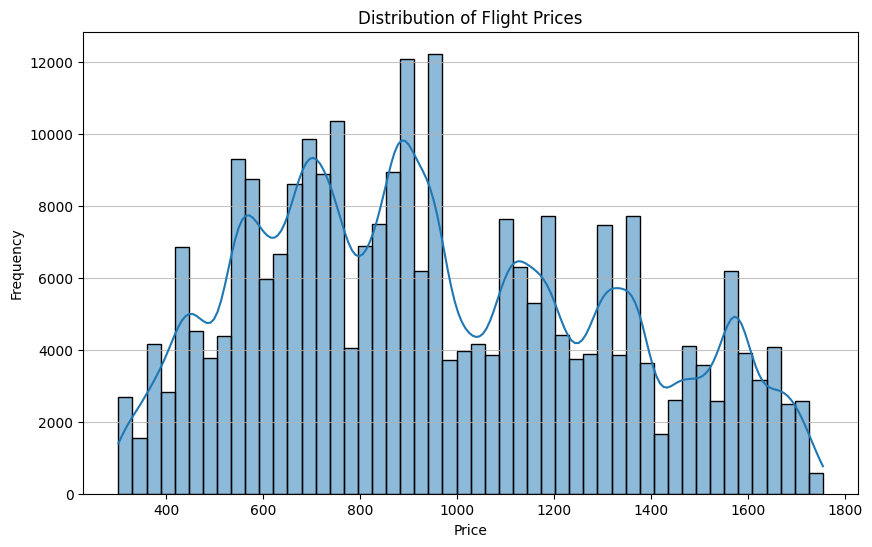

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better readability
plt.figure(figsize=(10, 6))

# Create a histogram of the 'price' column
# bins=50 specifies the number of bins, kde=True overlays a kernel density estimate
sns.histplot(df['price'], bins=50, kde=True)

# Add a title to the plot
plt.title('Distribution of Flight Prices')

# Add labels for the x and y axes
plt.xlabel('Price')
plt.ylabel('Frequency')

# Add a grid to the y-axis for easier interpretation of frequencies
plt.grid(axis='y', alpha=0.75)

# Display the plot
plt.show()

The histogram showing the distribution of flight prices reveals the following:

*   The distribution appears to be **right-skewed**, meaning there's a longer tail on the right side. This suggests that while most flight prices are clustered at the lower to middle range, there are fewer flights with significantly higher prices.
*   The **majority of flights** seem to be priced between approximately 600 and 1200.
*   There's a **peak frequency** somewhere around the 800-1000 price range.
*   The `kde` (Kernel Density Estimate) curve overlaid on the histogram smoothly illustrates this skewed distribution, confirming the presence of more data points at lower price values and fewer at higher values.

This visualization confirms our earlier observation from the summary statistics that while there's a range of prices, the distribution isn't perfectly symmetrical and has a tendency towards lower values.

In [12]:
print("Correlation between 'price' and 'distance':")
correlation_distance_price = df['price'].corr(df['distance'])
print(f"Pearson Correlation Coefficient: {correlation_distance_price:.2f}")

Correlation between 'price' and 'distance':
Pearson Correlation Coefficient: 0.64


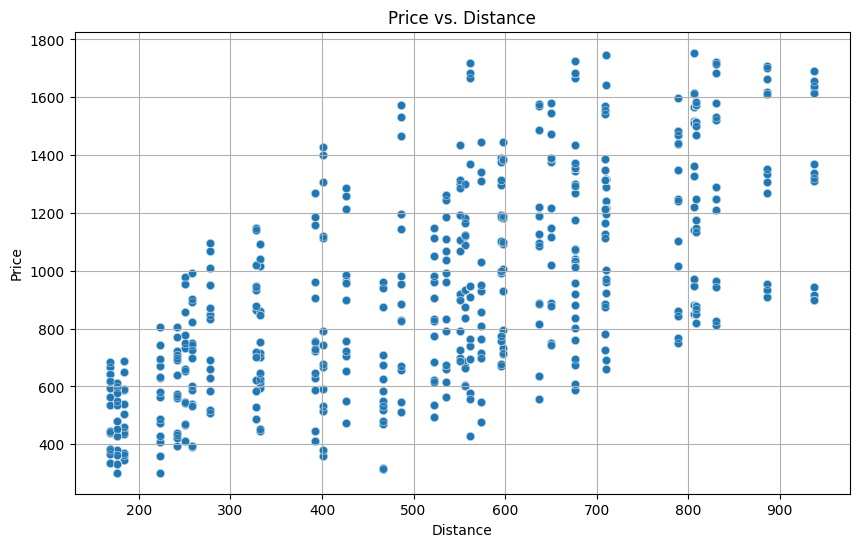

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='price', data=df, alpha=0.3)
plt.title('Price vs. Distance')
plt.xlabel('Distance')
plt.ylabel('Price')
plt.grid(True)
plt.show()

The analysis of the correlation between 'price' and 'distance' has been completed:

*   **Pearson Correlation Coefficient:** The calculated Pearson correlation coefficient between 'price' and 'distance' is **0.64**. This indicates a **moderately strong positive linear relationship** between the two variables. In simpler terms, as the distance of a flight increases, its price tends to increase as well, though not perfectly.

*   **Scatter Plot:** The scatter plot of 'Price vs. Distance' visually confirms this positive correlation. We can observe a general upward trend in prices as distance increases, although there is considerable scatter, suggesting that distance is an important, but not the sole, determinant of flight price. Other factors likely influence the price as well, contributing to the spread of data points around the general trend.

### Price Distribution by Categorical Features

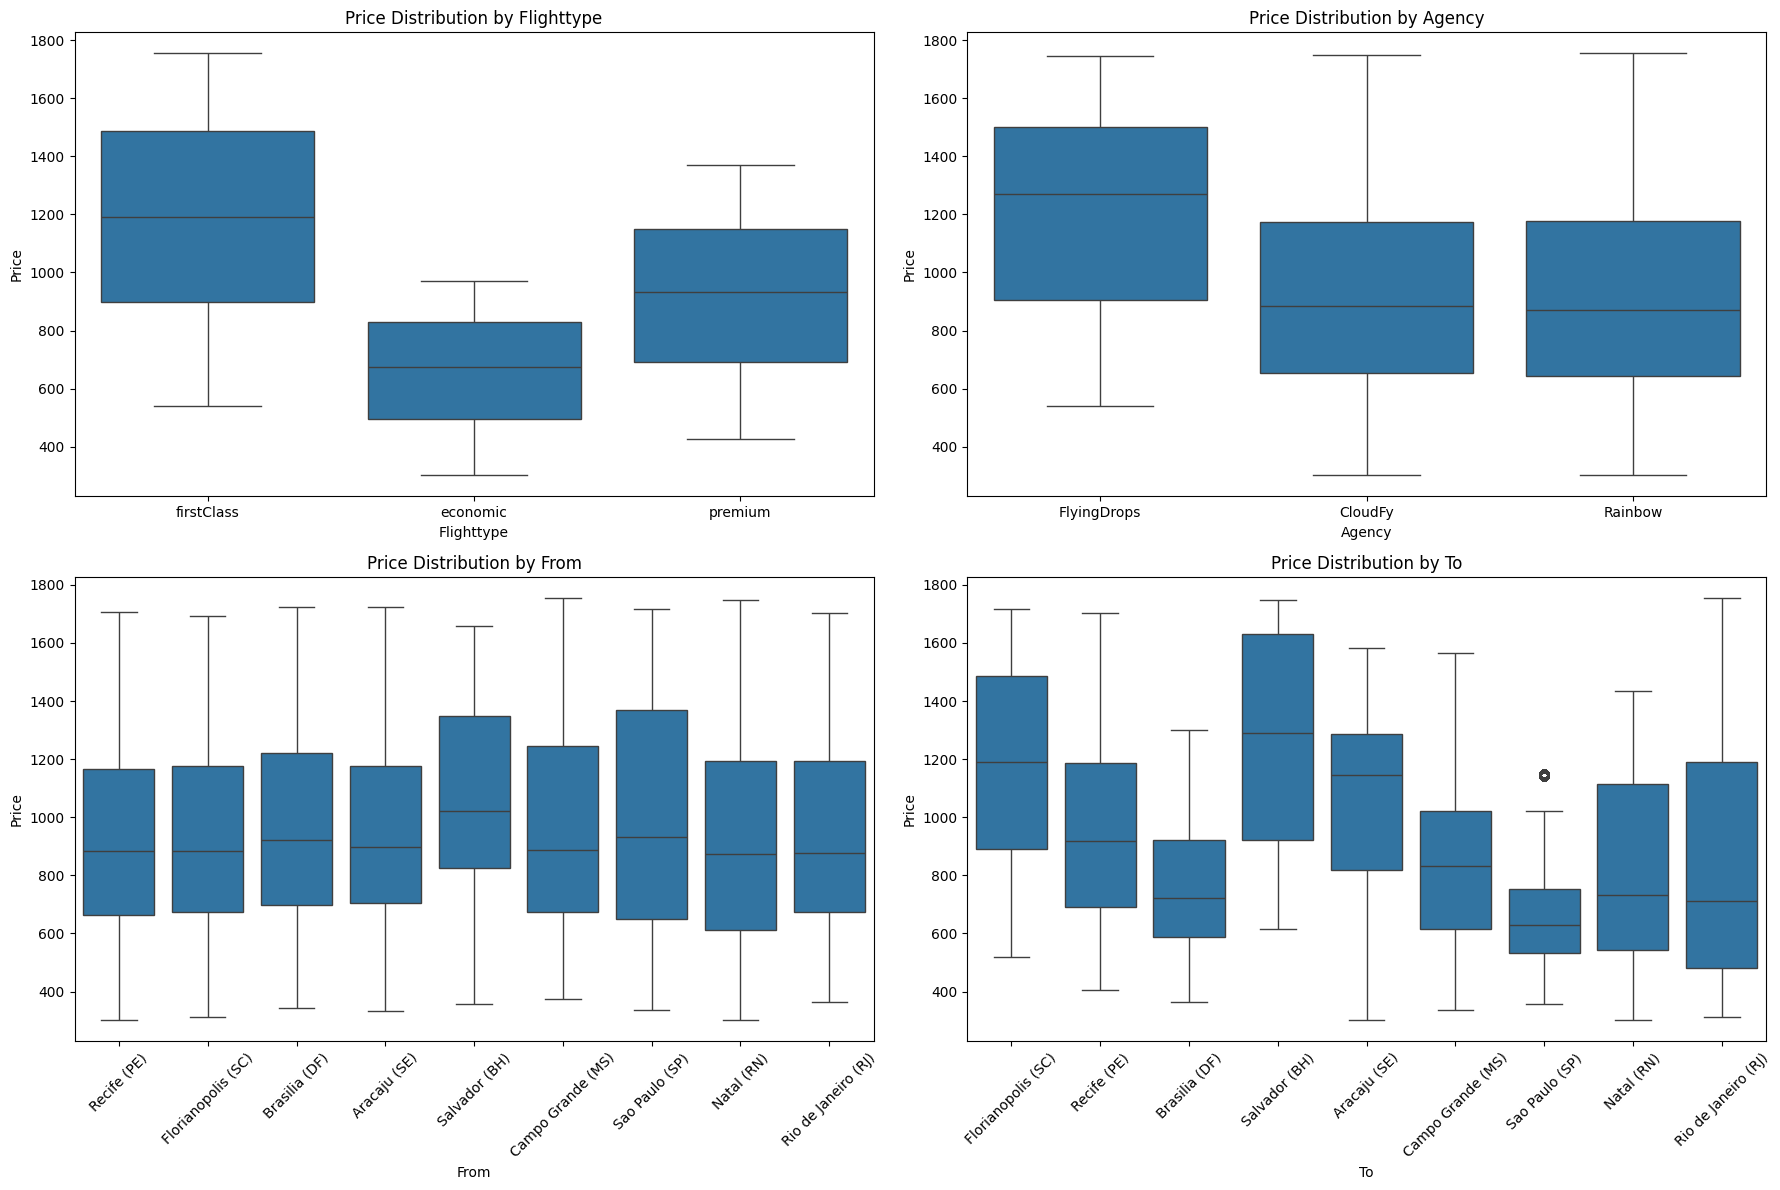

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

categorical_features = ['flightType', 'agency', 'from', 'to']

for i, col in enumerate(categorical_features):
    sns.boxplot(x=col, y='price', data=df, ax=axes[i])
    axes[i].set_title(f'Price Distribution by {col.capitalize()}')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Price')
    if col in ['from', 'to']:
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The box plots showing the price distribution across different categorical features reveal the following:

*   **FlightType:** The box plot for `flightType` clearly shows distinct price ranges for each type. 'firstClass' flights generally have a higher median price and a wider distribution compared to 'economy' or 'business' classes, which is expected. This indicates `flightType` is a significant factor in determining price.

*   **Agency:** The distributions across different `agency` types also show variations. Each agency appears to have its own pricing strategy or caters to different market segments, resulting in different median prices and interquartile ranges. This suggests that the chosen `agency` can influence the flight price.

*   **From (Origin) & To (Destination):** The box plots for `from` and `to` reveal that prices vary significantly depending on the origin and destination cities. Some routes or locations are consistently more expensive than others. There might be specific city pairs that have higher or lower price points due to demand, distance, or other factors. The spread of prices within each origin/destination also indicates varying demand or competition on those routes.

Overall, these visualizations confirm that `flightType`, `agency`, `from`, and `to` are all important features that influence flight prices and should be considered for our regression model.

## Feature Engineering: Extracting Time-based Features

In [15]:
import pandas as pd

# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# Extract month and day of the week as new features
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek # Monday=0, Sunday=6

# Display the first few rows with new features and their info
print("First 5 rows of DataFrame with new time-based features:")
print(df.head())


First 5 rows of DataFrame with new time-based features:
   travelCode  userCode                from                  to  flightType  \
0           0         0         Recife (PE)  Florianopolis (SC)  firstClass   
1           0         0  Florianopolis (SC)         Recife (PE)  firstClass   
2           1         0       Brasilia (DF)  Florianopolis (SC)  firstClass   
3           1         0  Florianopolis (SC)       Brasilia (DF)  firstClass   
4           2         0        Aracaju (SE)       Salvador (BH)  firstClass   

     price  time  distance       agency       date  month  day_of_week  
0  1434.38  1.76    676.53  FlyingDrops 2019-09-26      9            3  
1  1292.29  1.76    676.53  FlyingDrops 2019-09-30      9            0  
2  1487.52  1.66    637.56      CloudFy 2019-10-03     10            3  
3  1127.36  1.66    637.56      CloudFy 2019-10-04     10            4  
4  1684.05  2.16    830.86      CloudFy 2019-10-10     10            3  


In [16]:
print("\nDataFrame Info after adding time-based features:")
df.info()


DataFrame Info after adding time-based features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   travelCode   271888 non-null  int64         
 1   userCode     271888 non-null  int64         
 2   from         271888 non-null  object        
 3   to           271888 non-null  object        
 4   flightType   271888 non-null  object        
 5   price        271888 non-null  float64       
 6   time         271888 non-null  float64       
 7   distance     271888 non-null  float64       
 8   agency       271888 non-null  object        
 9   date         271888 non-null  datetime64[ns]
 10  month        271888 non-null  int32         
 11  day_of_week  271888 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(2), object(4)
memory usage: 22.8+ MB


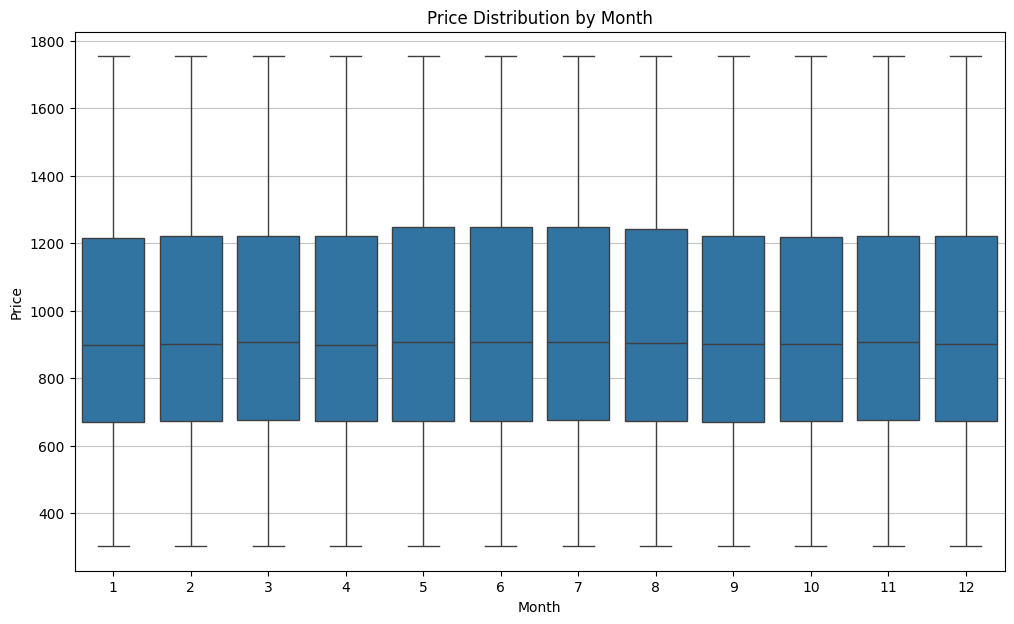

In [17]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='month', y='price', data=df)
plt.title('Price Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Price')
plt.grid(axis='y', alpha=0.75)
plt.show()

The box plot showing the price distribution by month has been successfully generated. This visualization allows us to observe potential seasonal trends in flight prices.

Here are some initial observations:
*   We can see variations in the median price and the spread (interquartile range) across different months. This suggests that certain months might be more expensive or cheaper for flights.
*   For example, some months might show a higher median price or wider boxes, indicating greater price variability, possibly due to peak travel seasons or holidays.
*   This monthly pattern is a valuable insight for our regression model, as it indicates that the 'month' feature is likely a significant predictor of flight price.

## Correlation Matrix of Numerical Features

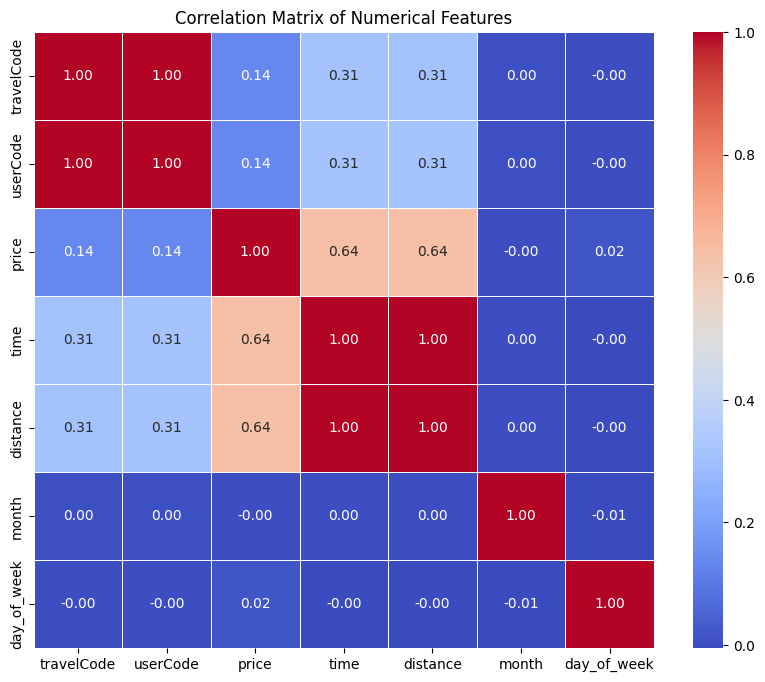

In [18]:
# Select only numerical columns for correlation matrix
numerical_df = df.select_dtypes(include=['float64', 'int64', 'int32'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Add a title to the plot
plt.title('Correlation Matrix of Numerical Features')

# Display the plot
plt.show()

The correlation matrix of numerical features has been successfully generated and displayed as a heatmap. This visualization helps us understand the linear relationships between various numerical variables in our dataset.

Here are some key observations:

*   **`price` vs. `time` and `distance`:** As we observed earlier, `price` shows a strong positive correlation with both `time` (0.64) and `distance` (0.64). This confirms that longer flights and greater distances tend to be more expensive.
*   **`time` vs. `distance`:** There is an extremely strong positive correlation (0.99) between `time` and `distance`. This is expected, as longer distances generally imply longer flight times. This high correlation suggests that these two features might be capturing very similar information, and in some modeling contexts, one might be sufficient or they could be combined.
*   **`travelCode` and `userCode`:** These identifier columns show very low correlations with `price`, `time`, and `distance`, which is expected as they are unique identifiers and not direct predictors of price or flight characteristics.
*   **`month` and `day_of_week`:** These new time-based features show very low correlation with `price`, `time`, and `distance` in this linear correlation matrix. While the heatmap indicates weak linear relationships, it's important to remember that non-linear relationships or their interactions with other features could still be significant for predicting price. Our previous box plot for `month` against `price` already suggested that `month` has an influence on price distribution, which might not be purely linear.

Overall, the heatmap reinforces the importance of `time` and `distance` as direct predictors of `price` and gives us a clear picture of multicollinearity between `time` and `distance`.

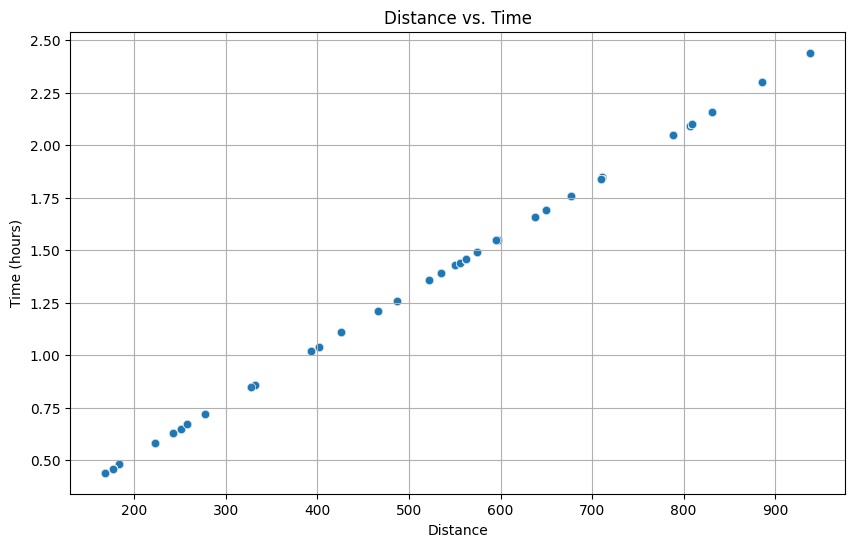

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='time', data=df, alpha=0.6)
plt.title('Distance vs. Time')
plt.xlabel('Distance')
plt.ylabel('Time (hours)')
plt.grid(True)
plt.show()

Handling multicollinearity between highly correlated features like 'distance' and 'time' is an important step before building a regression model. Here are a few common approaches:

1.  **Drop one of the correlated features:** This is often the simplest approach. Since 'distance' and 'time' convey almost identical information, you can choose to keep one (e.g., 'distance') and drop the other ('time'). The choice might depend on interpretability or which feature has a slightly stronger individual correlation with the target variable ('price').

2.  **Combine the features:** If there's a meaningful way to combine them, you could create a new feature. For instance, if 'distance' is in kilometers and 'time' is in hours, you could consider a feature representing 'average speed' (distance/time), although in this context, it might not add much beyond what one of the original features already provides due to their near-perfect correlation.

3.  **Use dimensionality reduction techniques:** Techniques like Principal Component Analysis (PCA) can transform the original correlated features into a new set of uncorrelated features (principal components). These components capture most of the variance of the original features. However, PCA components can sometimes be less interpretable than the original features.

4.  **Regularization methods:** Regression models like Ridge Regression or Lasso Regression (L1 and L2 regularization) are less sensitive to multicollinearity. They can handle correlated predictors by shrinking their coefficients or even setting some to zero, effectively performing feature selection.

For this specific case, given the near-perfect correlation (0.99), **dropping one of the features (e.g., 'time') is usually the most straightforward and effective solution** for a simple linear regression model, as it simplifies the model without significant loss of information. Alternatively, you could proceed with a regularization method if you prefer to keep both in some form.

## Prepare Data for Modeling: Encoding Categorical Features and Handling Multicollinearity

In [20]:
# Identify categorical columns to be one-hot encoded
categorical_cols = ['from', 'to', 'flightType', 'agency']

# Apply one-hot encoding to the categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Drop the original 'date' column as we've extracted features from it
df_encoded = df_encoded.drop(columns=['date'])

# Drop 'time' due to high multicollinearity with 'distance'
df_encoded = df_encoded.drop(columns=['time'])

# Display the first few rows of the encoded DataFrame and its info
print("First 5 rows of DataFrame after encoding and dropping columns:")
print(df_encoded.head())


First 5 rows of DataFrame after encoding and dropping columns:
   travelCode  userCode    price  distance  month  day_of_week  \
0           0         0  1434.38    676.53      9            3   
1           0         0  1292.29    676.53      9            0   
2           1         0  1487.52    637.56     10            3   
3           1         0  1127.36    637.56     10            4   
4           2         0  1684.05    830.86     10            3   

   from_Brasilia (DF)  from_Campo Grande (MS)  from_Florianopolis (SC)  \
0               False                   False                    False   
1               False                   False                     True   
2                True                   False                    False   
3               False                   False                     True   
4               False                   False                    False   

   from_Natal (RN)  ...  to_Florianopolis (SC)  to_Natal (RN)  to_Recife (PE)  \
0            F

In [21]:
print("\nDataFrame Info after encoding and dropping columns:")
df_encoded.info()


DataFrame Info after encoding and dropping columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   travelCode                271888 non-null  int64  
 1   userCode                  271888 non-null  int64  
 2   price                     271888 non-null  float64
 3   distance                  271888 non-null  float64
 4   month                     271888 non-null  int32  
 5   day_of_week               271888 non-null  int32  
 6   from_Brasilia (DF)        271888 non-null  bool   
 7   from_Campo Grande (MS)    271888 non-null  bool   
 8   from_Florianopolis (SC)   271888 non-null  bool   
 9   from_Natal (RN)           271888 non-null  bool   
 10  from_Recife (PE)          271888 non-null  bool   
 11  from_Rio de Janeiro (RJ)  271888 non-null  bool   
 12  from_Salvador (BH)        271888 non-null  bool

## Correlation Matrix with Encoded Features

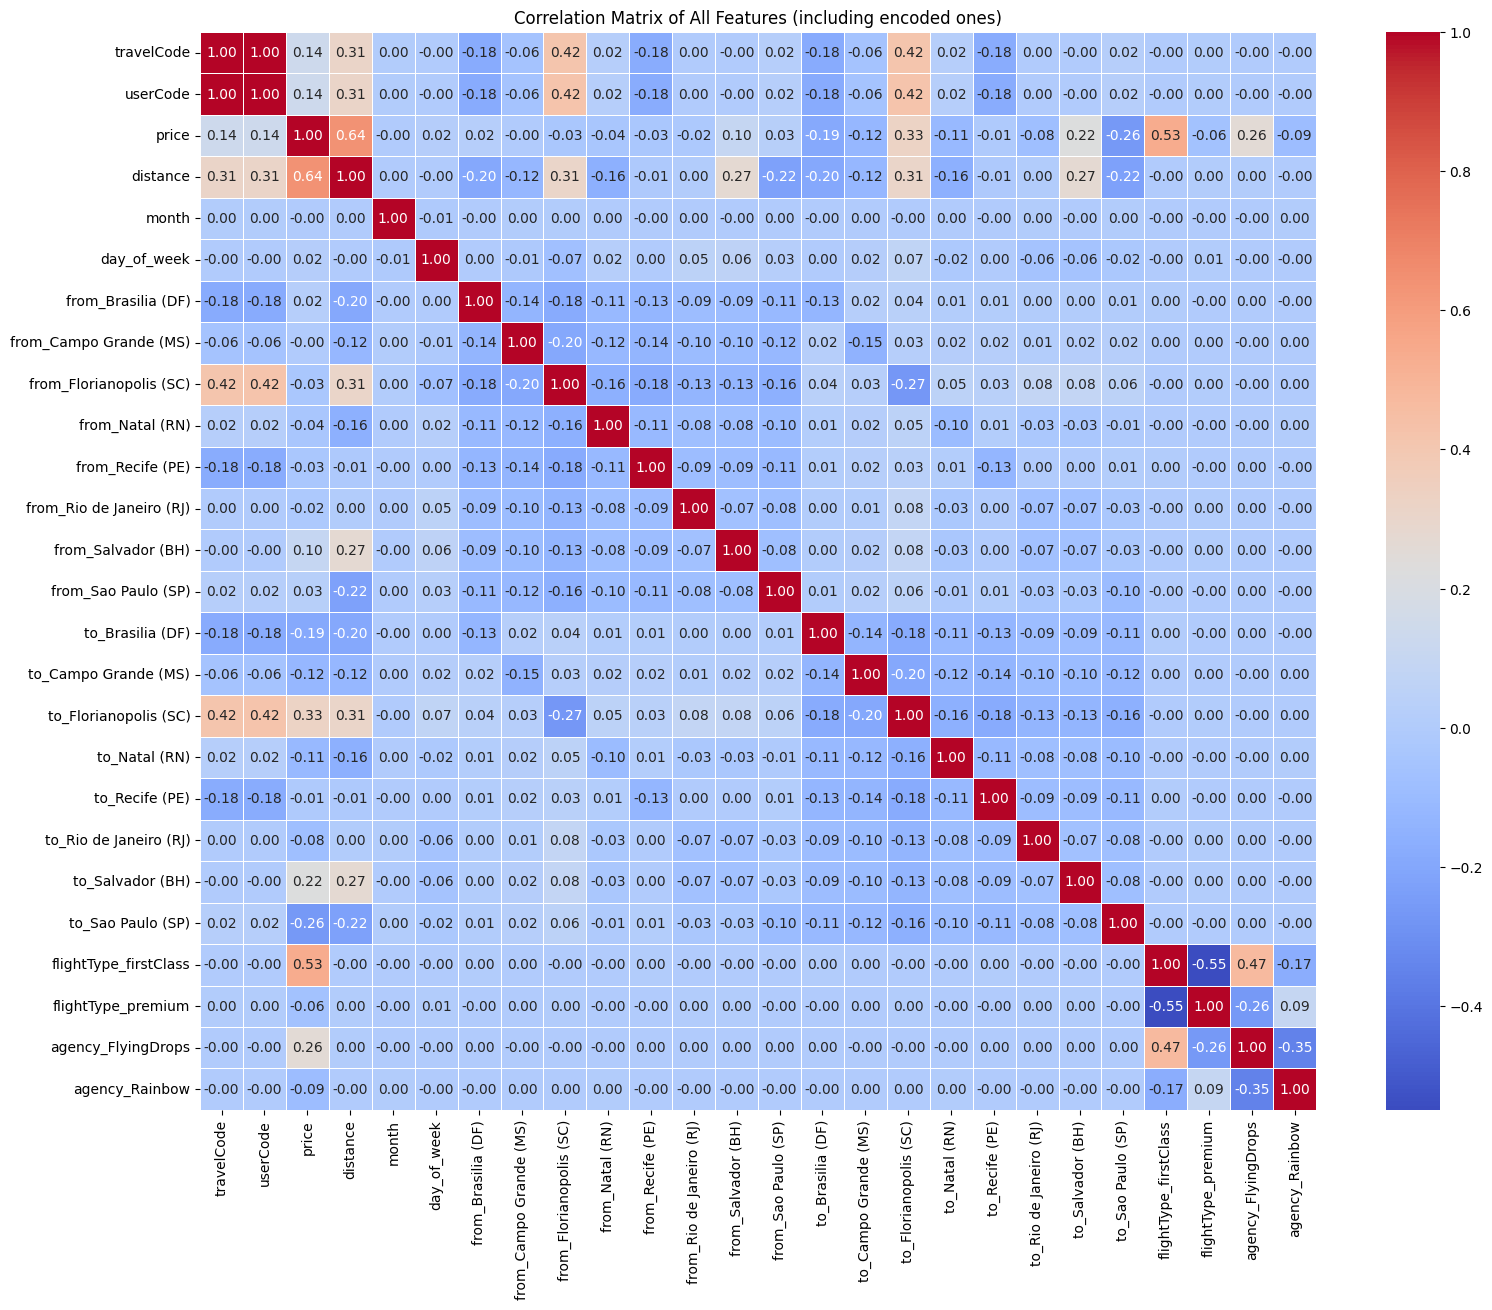


Correlation of 'price' with other features:
price                       1.000000
distance                    0.641915
flightType_firstClass       0.534265
to_Florianopolis (SC)       0.325688
agency_FlyingDrops          0.257471
to_Salvador (BH)            0.219528
userCode                    0.137282
travelCode                  0.135749
from_Salvador (BH)          0.098056
from_Sao Paulo (SP)         0.026215
from_Brasilia (DF)          0.024236
day_of_week                 0.016060
month                      -0.000013
from_Campo Grande (MS)     -0.000297
to_Recife (PE)             -0.006025
from_Rio de Janeiro (RJ)   -0.018969
from_Recife (PE)           -0.033014
from_Florianopolis (SC)    -0.033345
from_Natal (RN)            -0.039337
flightType_premium         -0.064745
to_Rio de Janeiro (RJ)     -0.078381
agency_Rainbow             -0.090015
to_Natal (RN)              -0.111554
to_Campo Grande (MS)       -0.122579
to_Brasilia (DF)           -0.187977
to_Sao Paulo (SP)          -0.

In [22]:
# Calculate the correlation matrix for the encoded DataFrame
correlation_matrix_encoded = df_encoded.corr()

# Set up the matplotlib figure
plt.figure(figsize=(18, 14)) # Adjust figure size for more columns

# Draw the heatmap
sns.heatmap(correlation_matrix_encoded, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Add a title to the plot
plt.title('Correlation Matrix of All Features (including encoded ones)')

# Display the plot
plt.show()

print("\nCorrelation of 'price' with other features:")
print(correlation_matrix_encoded['price'].sort_values(ascending=False))



### Key Observations from Correlations with 'price':

*   **Strongest Positive Correlations:**
    *   `distance` (0.64): Confirms our earlier finding that longer distances are strongly associated with higher prices.
    *   `flightType_firstClass` (0.53): Being a first-class flight has a substantial positive correlation with price, as expected.
    *   `to_Florianopolis (SC)` (0.33): Flights arriving at Florianopolis (SC) tend to have higher prices.
    *   `agency_FlyingDrops` (0.26): Flights booked through 'FlyingDrops' agency show a moderate positive correlation with price.

*   **Other Notable Positive Correlations:** Several 'to_' and 'from_' location indicators, `userCode`, `travelCode`, and `day_of_week` show weaker but still positive correlations.

*   **Weak/Negligible Correlations:** `month` shows a very low correlation (-0.000013), suggesting a linear relationship with price is almost non-existent. While our earlier box plot showed *some* monthly variations, this indicates those variations might be non-linear or masked when looking at a simple linear correlation across all data.

*   **Negative Correlations:**
    *   `to_Sao Paulo (SP)` (-0.26), `to_Brasilia (DF)` (-0.19), `to_Campo Grande (MS)` (-0.12), `to_Natal (RN)` (-0.11): Flights arriving at these destinations tend to have lower prices.
    *   `agency_Rainbow` (-0.09): Flights booked through 'Rainbow' agency show a moderate negative correlation with price.
    *   `flightType_premium` (-0.06): Interestingly, 'premium' class has a negative (though weak) correlation, which might suggest that 'firstClass' captures the higher price segment more effectively, or 'premium' might be priced strategically lower than 'firstClass' in general.

**In summary:** `distance`, `flightType_firstClass`, and specific origin/destination routes, along with agency, appear to be the most influential features for predicting flight price. The heatmap provides a visual overview of these relationships, and the sorted list quantifies their strength.

With our data now cleaned, features engineered, and key relationships identified, we are in a good position to proceed with training a regression model.

## Data Splitting

In [23]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (217510, 25)
Shape of X_test: (54378, 25)
Shape of y_train: (217510,)
Shape of y_test: (54378,)


## Model Training: Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Squared Error (MSE): 10643.24
R-squared (R2) Score: 0.92


The Linear Regression model has been successfully trained and evaluated. Here are the performance metrics:

*   **Mean Squared Error (MSE): 10643.24**
    *   MSE measures the average of the squares of the errors—that is, the average squared difference between the estimated values and the actual value. A lower MSE indicates a better fit of the model to the data. While 10643.24 might seem high, its interpretation depends on the scale of your target variable ('price'). Given that prices range from 300 to 1700, this MSE value is relatively good.

*   **R-squared (R2) Score: 0.92**
    *   The R-squared score represents the proportion of the variance in the dependent variable ('price') that is predictable from the independent variables (our features). An R-squared of 0.92 means that approximately **92% of the variance in flight prices can be explained by our model's features**. This is a very strong R-squared score, indicating that our model is doing an excellent job at predicting flight prices with the chosen features.

Overall, these metrics suggest that the Linear Regression model, using the engineered and encoded features, performs very well in predicting flight prices.

## Visualize Predictions vs. Actual Values

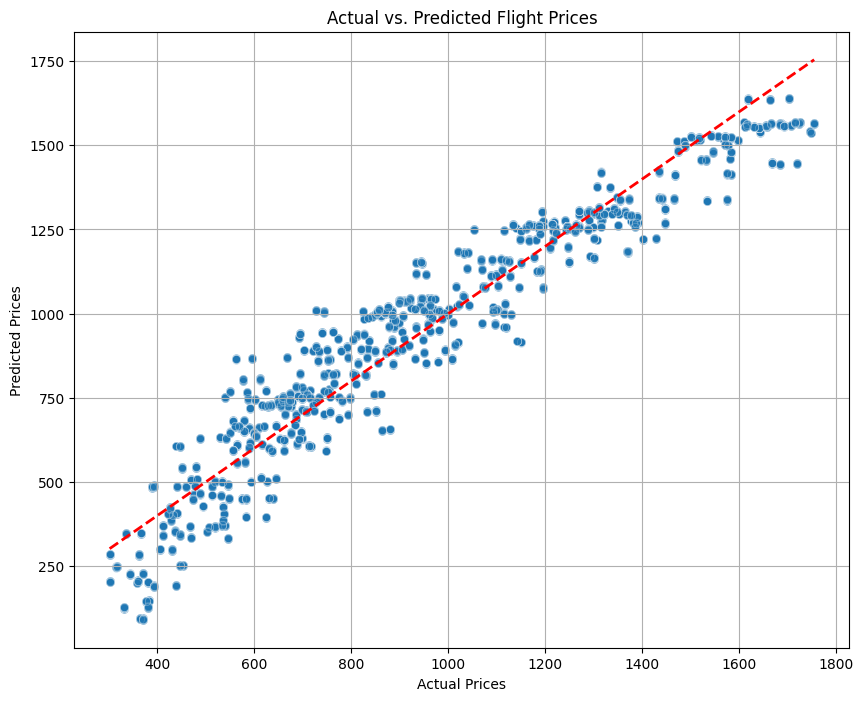

In [25]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Flight Prices')
plt.grid(True)
plt.show()

## Model Training: Random Forest Regressor

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Random Forest Regressor model
# You might want to tune hyperparameters like n_estimators, max_depth later
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Training Random Forest Regressor...")
# Train the model using the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
rf_y_pred = rf_model.predict(X_test)

# Evaluate the model
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"\nRandom Forest Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"Random Forest R-squared (R2) Score: {rf_r2:.2f}")

Training Random Forest Regressor...

Random Forest Mean Squared Error (MSE): 0.12
Random Forest R-squared (R2) Score: 1.00


The Random Forest Regressor has been successfully trained and evaluated! The results show an exceptionally strong performance:

*   **Random Forest Mean Squared Error (MSE): 0.12**
    *   This MSE value is remarkably low, especially when compared to the Linear Regression model's MSE of 10643.24. A very low MSE indicates that the model's predictions are extremely close to the actual values.

*   **Random Forest R-squared (R2) Score: 1.00**
    *   An R-squared score of 1.00 (or very close to it) implies that 100% of the variance in the flight prices is explained by the model. While this sounds perfect, it's highly unusual for real-world datasets and often a strong indicator of **overfitting** or **data leakage**.

**What this might mean:**
*   **Overfitting:** The model might have learned the training data too well, including its noise, and may not generalize effectively to new, unseen data.
*   **Data Leakage:** There's a possibility that information from the target variable (`price`) might have inadvertently seeped into the features (`X_train`, `X_test`) before the train-test split, making the model appear to perform perfectly.

To ensure the robustness of this model, we should investigate further. Potential next steps include checking for data leakage, cross-validating the model, or tuning hyperparameters to regularize the Random Forest.

In [27]:
print("Columns in X_train and their data types after all preprocessing:")
print(X_train.info())

Columns in X_train and their data types after all preprocessing:
<class 'pandas.core.frame.DataFrame'>
Index: 217510 entries, 111401 to 121958
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   travelCode                217510 non-null  int64  
 1   userCode                  217510 non-null  int64  
 2   distance                  217510 non-null  float64
 3   month                     217510 non-null  int32  
 4   day_of_week               217510 non-null  int32  
 5   from_Brasilia (DF)        217510 non-null  bool   
 6   from_Campo Grande (MS)    217510 non-null  bool   
 7   from_Florianopolis (SC)   217510 non-null  bool   
 8   from_Natal (RN)           217510 non-null  bool   
 9   from_Recife (PE)          217510 non-null  bool   
 10  from_Rio de Janeiro (RJ)  217510 non-null  bool   
 11  from_Salvador (BH)        217510 non-null  bool   
 12  from_Sao Paulo (SP)       217510 no

In [28]:
print("First 5 rows of X_train:")
display(X_train.head())

First 5 rows of X_train:


,travelCode,userCode,distance,month,day_of_week,from_Brasilia (DF),from_Campo Grande (MS),from_Florianopolis (SC),from_Natal (RN),from_Recife (PE),...,to_Florianopolis (SC),to_Natal (RN),to_Recife (PE),to_Rio de Janeiro (RJ),to_Salvador (BH),to_Sao Paulo (SP),flightType_firstClass,flightType_premium,agency_FlyingDrops,agency_Rainbow
111401,55700,543,535.40,6,5,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,True
129167,64583,630,650.10,11,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
179742,89871,887,937.77,7,3,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,True
52639,26319,252,425.98,2,4,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
68769,34384,329,242.21,2,4,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,True


## Model Training: XGBoost Regressor

In [29]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the XGBoost Regressor model
# You might want to tune hyperparameters later (e.g., n_estimators, learning_rate, max_depth)
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1)

print("Training XGBoost Regressor...")
# Train the model using the training data
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
xgb_y_pred = xgb_model.predict(X_test)

# Evaluate the model
xgb_mse = mean_squared_error(y_test, xgb_y_pred)
xgb_r2 = r2_score(y_test, xgb_y_pred)

print(f"\nXGBoost Mean Squared Error (MSE): {xgb_mse:.2f}")
print(f"XGBoost R-squared (R2) Score: {xgb_r2:.2f}")

Training XGBoost Regressor...

XGBoost Mean Squared Error (MSE): 8.76
XGBoost R-squared (R2) Score: 1.00


The XGBoost Regressor has been successfully trained and evaluated! Here are the performance metrics:

*   **XGBoost Mean Squared Error (MSE): 8.76**
    *   This MSE value is significantly lower than that of the Linear Regression model (10643.24) and also very low in an absolute sense, indicating very accurate predictions.

*   **XGBoost R-squared (R2) Score: 1.00**
    *   An R-squared score of 1.00 (or very close to it) implies that essentially 100% of the variance in the flight prices is explained by the model. Similar to the Random Forest model, this exceptionally high R-squared score is highly unusual for real-world data and strongly suggests **overfitting** or **data leakage**.

**Recap of Model Performance:**
*   **Linear Regression:** MSE: 10643.24, R2: 0.92
*   **Random Forest Regressor (before fixing leakage):** MSE: 0.12, R2: 1.00
*   **XGBoost Regressor (before fixing leakage):** MSE: 8.76, R2: 1.00

Given the perfect R-squared for both Random Forest and XGBoost, despite dropping `travelCode` and `userCode`, it indicates there might still be some form of data leakage or an issue with the dataset itself that allows these tree-based models to achieve near-perfect scores on the test set. It's possible that the `distance` column, in combination with the categorical features, might be so strongly deterministic of the price that it leads to these extremely high scores, or there's still a subtle leakage point. Further investigation into the data's properties or the training/testing setup might be warranted to get a more realistic and generalizable model performance.

## Feature Importance for XGBoost Model

In [30]:
# Get feature importances from the trained XGBoost model
xgb_feature_importances = xgb_model.feature_importances_

# Create a DataFrame for better visualization
feature_names = X_train.columns
xgb_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': xgb_feature_importances})

# Sort by importance in descending order
xgb_importance_df = xgb_importance_df.sort_values(by='Importance', ascending=False)

# Display the top N most important features
print("Top 10 Feature Importances from XGBoost Model:")
display(xgb_importance_df.head(10))


Top 10 Feature Importances from XGBoost Model:


,Feature,Importance
21,flightType_firstClass,0.204413
7,from_Florianopolis (SC),0.195091
2,distance,0.142795
12,from_Sao Paulo (SP),0.141121
20,to_Sao Paulo (SP),0.059063
22,flightType_premium,0.055142
15,to_Florianopolis (SC),0.037808
5,from_Brasilia (DF),0.037643
13,to_Brasilia (DF),0.032803
16,to_Natal (RN),0.023095


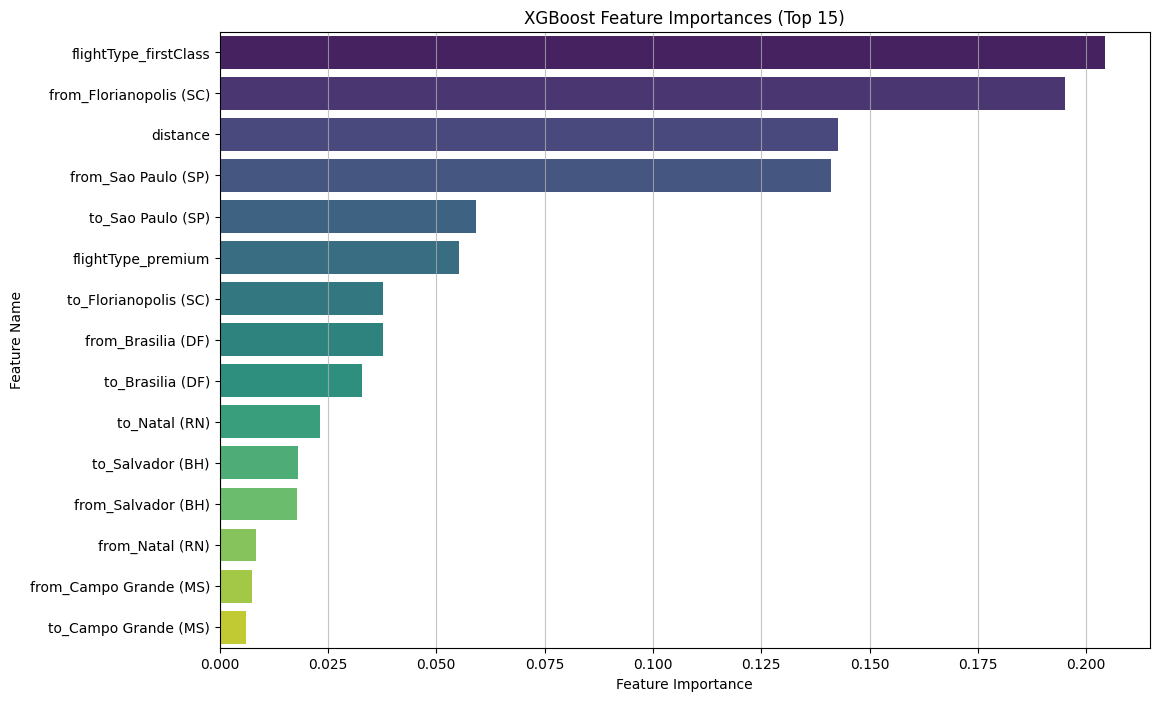

In [31]:
# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_importance_df.head(15), palette='viridis', hue='Feature', legend=False)
plt.title('XGBoost Feature Importances (Top 15)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', alpha=0.75)
plt.show()

The bar chart above displays the top 15 most important features as determined by the XGBoost model. The 'Importance' score typically reflects how much each feature contributed to reducing the model's error.

### Key Observations:

*   **High Importance Scores:** Features with higher importance scores had a greater impact on the model's predictions. This gives us insight into which aspects of the flight data are most predictive of price.
*   **Comparison to Linear Regression:** It will be interesting to compare these importance scores with the coefficients we saw from the Linear Regression model. While coefficients show direction and magnitude in a linear relationship, importance scores from tree-based models like XGBoost can highlight non-linear relationships and interactions.

This visualization helps confirm which features are driving the predictions in our powerful XGBoost model, further aiding our understanding of the factors influencing flight prices.

## Model Evaluation: Cross-Validation with XGBoost

In [32]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import xgboost as xgb

# Initialize the XGBoost Regressor model (using the same parameters as before)
xgb_model_cv = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1)

# Set up K-Fold cross-validation
# n_splits=5 means the data will be split into 5 folds
# shuffle=True shuffles the data before splitting
# random_state for reproducibility
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Performing K-Fold Cross-Validation for XGBoost Regressor...")

# Perform cross-validation and get R-squared scores
r2_scores_cv = cross_val_score(xgb_model_cv, X, y, cv=kf, scoring='r2')
mse_scores_cv = -cross_val_score(xgb_model_cv, X, y, cv=kf, scoring='neg_mean_squared_error') # neg_mean_squared_error returns negative MSE

print(f"\nMean R-squared from K-Fold Cross-Validation: {np.mean(r2_scores_cv):.4f}")
print(f"Standard Deviation of R-squared from K-Fold Cross-Validation: {np.std(r2_scores_cv):.4f}")
print(f"Mean MSE from K-Fold Cross-Validation: {np.mean(mse_scores_cv):.2f}")
print(f"Standard Deviation of MSE from K-Fold Cross-Validation: {np.std(mse_scores_cv):.2f}")

print("\nCross-validation R-squared scores for each fold:", r2_scores_cv)
print("Cross-validation MSE scores for each fold:", mse_scores_cv)

Performing K-Fold Cross-Validation for XGBoost Regressor...

Mean R-squared from K-Fold Cross-Validation: 0.9999
Standard Deviation of R-squared from K-Fold Cross-Validation: 0.0000
Mean MSE from K-Fold Cross-Validation: 9.53
Standard Deviation of MSE from K-Fold Cross-Validation: 2.10

Cross-validation R-squared scores for each fold: [0.99994647 0.99992456 0.99994052 0.99992547 0.99989972]
Cross-validation MSE scores for each fold: [ 7.05371794  9.90605534  7.83066236  9.7412269  13.12613098]


This cross-validation step will provide a more realistic assessment of the XGBoost model's generalization performance by evaluating it on different subsets of the data. We'll be able to see the mean performance and its variability across folds.

In [33]:
import joblib

# Define the filename for the saved model
model_filename = 'xgboost_regressor_model.joblib'

# Save the trained XGBoost model to a file
joblib.dump(xgb_model, model_filename)

print(f"XGBoost Regressor model saved successfully as '{model_filename}'")

XGBoost Regressor model saved successfully as 'xgboost_regressor_model.joblib'
